In [543]:
#Import numpy and Matplotlib modules
import numpy as np
import matplotlib.pyplot as plt
#ignore warning message
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Q1. Distance Matrix with NumPy Broadcasting

In [544]:
A = np.array([[1, 2],
 [4, 6],
 [7, 1]])

B = np.array([[0, 0],
 [5, 5]])

In [545]:
# 1) reshape for broadcasting
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :] 

In [546]:
#2) difference
diff =  A_exp - B_exp

In [547]:
#3) distance matrix

res = np.sqrt(np.sum(diff**2, axis=2))
res

array([[2.23606798, 5.        ],
       [7.21110255, 1.41421356],
       [7.07106781, 4.47213595]])

In [548]:
np.mean(res, axis=0)

array([5.50607945, 3.62878317])

4) average distance per warehouse
   
Warehouse B1 is located on average closer to all delivery points.

# Q2. Given:

In [549]:
p = np.array([2, 1, -3])
q = np.array([4, -2, 1])

1. Compute p · q using four different methods (loop, np.dot , np.multiply + sum , np.matmul ).

In [550]:
m1 = sum(p[i] * q[i] for i in range(len(p)))
m2 = np.dot(p, q)
m3 = np.multiply(p, q).sum()
m4 = np.matmul(p, q)

print(f'{m1, m2, m3, m4}') 

(np.int64(3), np.int64(3), np.int64(3), np.int64(3))


2. Using the geometric formula p · q = ||p|| × ||q|| × cos(θ) , compute the angle θ between p and q in both
radians and degrees

In [551]:
norm_p = np.linalg.norm(p)
norm_q = np.linalg.norm(q)
cos_theta = np.dot(p, q) / (norm_p * norm_q)
rad = np.arccos(cos_theta)
deg = np.degrees(rad)
print(f":{rad}, {deg}")

:1.3949275767021716, 79.92346287144585


3. Interpret the angle: are the vectors more aligned, perpendicular, or opposing?

The angle is almost equal to 80 degrees, which means the vectors are located almost perpendicularly

4. Now create a vector r that is guaranteed to be orthogonal to p (dot product = 0) in 3D. Verify it numerically.


In [552]:
p = np.array([2, 1, -3])

# (2 * -1) + (1 * 2) + (-3 * 0) = -2 + 2 + 0 = 0
r = np.array([-1, 2, 0]) 

np.dot(p, r)

np.int64(0)

# Q3. Given vectors

In [553]:
u = [3, -4]
v = [-6, 8]

In [554]:
# 1. Compute the magnitudes of u and v . What is the ratio ||v|| / ||u|| ? What does this ratio tell you?
mag_u = np.linalg.norm(u)
mag_v = np.linalg.norm(v)

mag_v / mag_u
# shows how many times V is longer than U

np.float64(2.0)

In [555]:
# 2. Compute the unit vectors of u and v . What do you notice?
u_unit = u / mag_u
v_unit = v / mag_v

print(f'{u_unit, v_unit}')
# They are collinear and directed in different directions.

(array([ 0.6, -0.8]), array([-0.6,  0.8]))


In [556]:
# 3) parallel check using dot product
cos_t = np.dot(u_unit, v_unit)

cos_t
# Since the cosine of theta is -1, they are parallel and directed in different directions.

np.float64(-1.0)

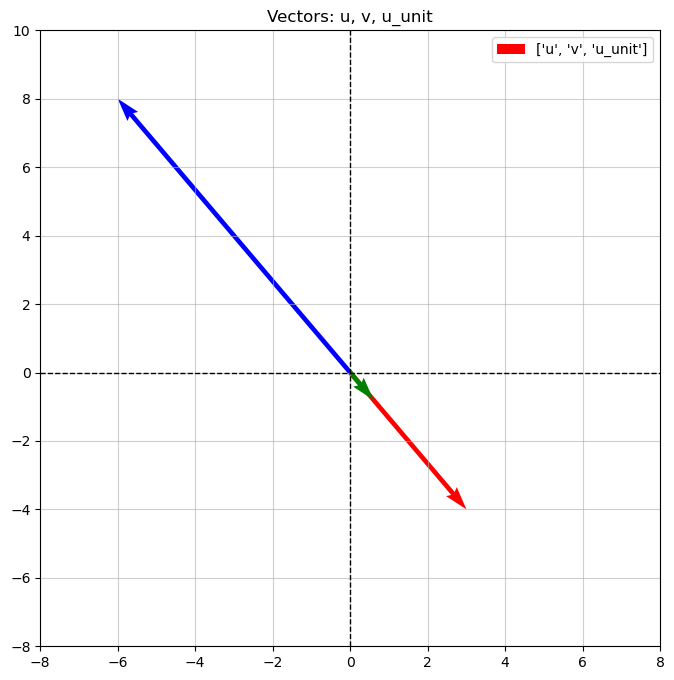

In [557]:
# 4) Plot

plt.figure(figsize=(8, 8))

origin = np.array([[0, 0, 0], [0, 0, 0]])
vectors = np.array([u, v, u_unit])

plt.quiver(*origin, vectors[:, 0], vectors[:, 1], 
           color=['r', 'b', 'g'], 
           angles='xy', scale_units='xy', scale=1, 
           label=['u', 'v', 'u_unit'])

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.grid(True, alpha=0.6)
plt.xlim(-8, 8)
plt.ylim(-8, 10)
plt.legend()
plt.title("Vectors: u, v, u_unit")
plt.show()

# Q4. Pandas: Load, Explore & Clean


In [558]:
df = sns.load_dataset('mpg')

In [559]:
# 1. Print the shape and display the first 5 rows.
print(df.shape)
print(df.head())

(398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [560]:
# 2. Print the number of missing values per column. Which column has missing values?
print(df.isnull().sum()) 
# The column 'horsepower' has missing values.

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [561]:
# 3. Create df_clean by dropping rows with any missing values using .dropna() . Print the new shape.

df_clean = df.dropna()
print(f": {df_clean.shape}")

: (392, 9)


In [562]:
# 4. Print basic summary statistics using .describe() . What is the average mpg ?

print(df_clean.describe())
avg_mpg = df_clean['mpg'].mean()
print({avg_mpg})

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.541327   75.979592  
std        2.758864    3.683737  
min        8.000000   70.000000  
25%       13.775000   73.000000  
50%       15.500000   76.000000  
75%       17.025000   79.000000  
max       24.800000   82.000000  
{np.float64(23.445918367346938)}


# Q5. Filtering, Sorting & GroupBy

In [563]:
# 1. Filter cars with mpg > 30 (fuel-efficient cars). Print how many there are.

efficient_cars = df_clean[df_clean['mpg'] > 30]
print(len(efficient_cars)) 

83


In [564]:
# Sort the dataset by mpg in descending order and display the top 5 most fuel-efficient cars — show only the columns name , mpg , cylinders , origin .

top_5_efficient = df_clean.sort_values(by='mpg', ascending=False).head(5)
print(top_5_efficient[['name', 'mpg', 'cylinders', 'origin']])

                     name   mpg  cylinders  origin
322             mazda glc  46.6          4   japan
329   honda civic 1500 gl  44.6          4   japan
325  vw rabbit c (diesel)  44.3          4  europe
394             vw pickup  44.0          4  europe
326    vw dasher (diesel)  43.4          4  europe


In [565]:
# 3. Use GroupBy to find the average mpg per country of origin ( origin ). Print the result.

origin_stats = df_clean.groupby('origin')['mpg'].mean()
print(origin_stats)

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64


4. In one Markdown sentence, state which country produces the most fuel-efficient cars on average.

Japan produces the most fuel-efficient cars, with the highest average MPG.

# Q6. Visualization


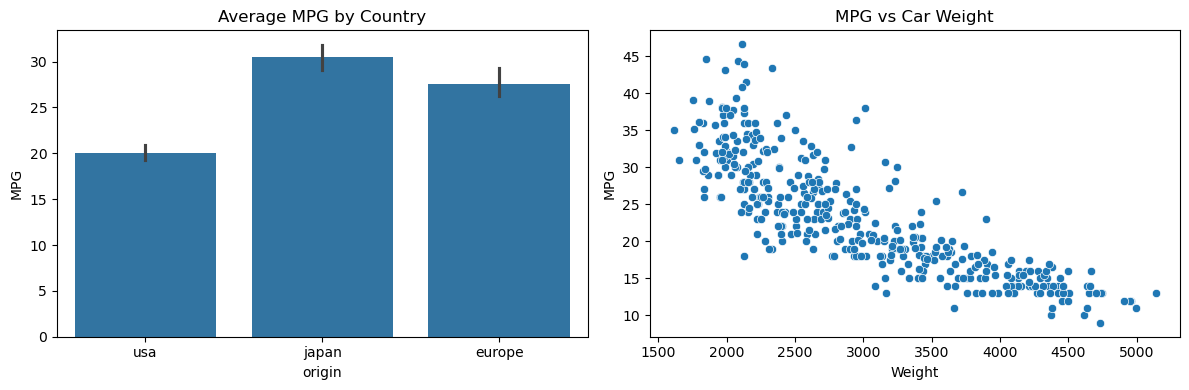

In [566]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 

sns.barplot(data=df_clean, x='origin', y='mpg', ax=ax1)
ax1.set_title('Average MPG by Country')
ax1.set_ylabel('MPG')

sns.scatterplot(data=df_clean, x='weight', y='mpg', ax=ax2)
ax2.set_title('MPG vs Car Weight')
ax2.set_xlabel('Weight')
ax2.set_ylabel('MPG')

plt.tight_layout()
plt.show()

In a Markdown cell, write one observation from the scatter plot.


The scatter plot shows a negative correlation: as a vehicle's weight increases, its MPG decreases.

# Q7. KNN Classification on the Wine Dataset

In [567]:
# 1. Load the dataset and print feature_names , target_names , and the shape of the data. In [19]: In [20]: In [21]: In [ ]:

wine = load_wine()

print(wine.feature_names)
print(wine.target_names)

print(wine.data.shape)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
(178, 13)


In [568]:
# 2. Split into train/test sets (75% train, 25% test) using random_state=42 .

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.25, random_state=42
) 

In [569]:
# 3. Train a KNeighborsClassifier with n_neighbors=5 . Print the test accuracy.

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)
print(f"Accuracy = {accuracy}") 

Accuracy = 0.7111111111111111


4. In a Markdown cell, state in one sentence whether this is a classification or regression problem and why.

Classification. This is a classification problem, since we are predicting whether an object belongs to one of three categories